In [1]:
import numpy as np
import xarray as xr
import pandas as pd

In [2]:
import matplotlib.pyplot as mp
from matplotlib import cm
from mpl_toolkits.axes_grid1 import AxesGrid
#from mpl_toolkits.basemap import Basemap as bmap
import matplotlib as mpl

In [ ]:
dir0 = '/glade/derecho/scratch/rneale/archive/'




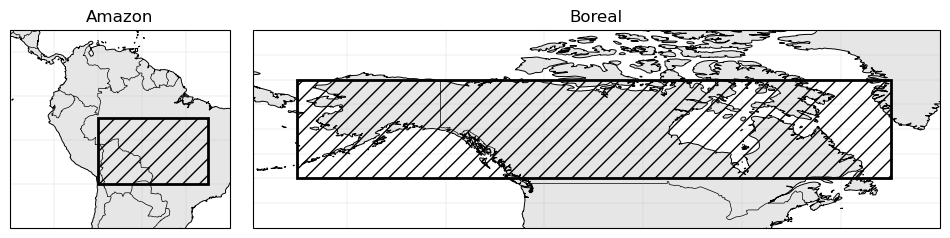

In [40]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

# Your explicit domains

ammin_lon = 290. ;   ammax_lon = 315. ;   ammin_lat = -20.   ; ammax_lat = -5. ; apmin_lon = 270 ;   apmax_lon = 320. ;   apmin_lat = -30.  ; apmax_lat = 15.
bmmin_lon = 190. ;   bmmax_lon = 310. ;   bmmin_lat = 50.   ; bmmax_lat = 70. ; bpmin_lon = 181. ;   bpmax_lon = 320. ;   bpmin_lat = 40.  ; bpmax_lat = 80.

domains = {
    "Amazon_p": (apmin_lon, apmax_lon, apmin_lat, apmax_lat),
    "Amazon_m": (ammin_lon, ammax_lon, ammin_lat, ammax_lat),
    "Boreal_p": (bpmin_lon, bpmax_lon, bpmin_lat, bpmax_lat),
    "Boreal_m": (bmmin_lon, bmmax_lon, bmmin_lat, bmmax_lat),
}

def add_box(ax, box, filled=False):
    lon0, lon1, lat0, lat1 = box
    rect = patches.Rectangle(
        (lon0, lat0), lon1 - lon0, lat1 - lat0,
        hatch = '//',
        transform=ccrs.PlateCarree(),
        linewidth=2 if not filled else 0,
        edgecolor="black" if not filled else "none",
        facecolor="gray" if filled else "none",
        alpha=0.5 if filled else 1.0,
        zorder=3,
    )
    ax.add_patch(rect)

# --- Figure with gridspec to force equal y-axis height in inches ---
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(
    1, 2, figure=fig,
    width_ratios=[0.89*(domains["Amazon_p"][1] - domains["Amazon_p"][0]),
                  domains["Boreal_p"][1] - domains["Boreal_p"][0]],
    wspace=0.05
)

ax_am = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax_bo = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())

for ax in (ax_am, ax_bo):
    ax.add_feature(cfeature.LAND, facecolor="0.9", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=1)
    ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5, zorder=2)

# Amazon subplot
ax_am.set_title("Amazon")
#add_box(ax_am, domains["Amazon_p"], filled=False)
add_box(ax_am, domains["Amazon_m"], filled=False)
ax_am.set_extent(domains["Amazon_p"], crs=ccrs.PlateCarree())

# Boreal subplot
ax_bo.set_title("Boreal")
#add_box(ax_bo, domains["Boreal_p"], filled=False)
add_box(ax_bo, domains["Boreal_m"], filled=False)
ax_bo.set_extent(domains["Boreal_p"], crs=ccrs.PlateCarree())

plt.show()
